In [1]:
# ============================================================
# UHI ANALYSIS - PIPELINE COMPLETO
# Sentinel-2 + MODIS | Barcelona
# Adaptable a cualquier ciudad cambiando CONFIG
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer

# ============================================================
# 0. CONFIGURACIÓN — cambiar aquí para adaptar a otra ciudad
# ============================================================
CIUDAD         = 'barcelona'
GRID_SIZE      = 1000          # metros
TOLERANCIA_DIAS = 8            # días de tolerancia para join temporal
CRS_UTM        = 32631         # UTM zone 31N (válido para BCN y Madrid)

PATHS = {
    'sentinel': 'data/BCN_sentinel_completo_2020_2025.csv',
    'modis':    'data/barcelona_temp_2020_2025_test.csv',
    'output':   f'data/{CIUDAD}_dataset_final.csv'
}

# ============================================================
# 1. CARGA DE DATOS
# ============================================================
df_sentinel = pd.read_csv(PATHS['sentinel'])
df_modis    = pd.read_csv(PATHS['modis'])

print(f'Sentinel raw: {df_sentinel.shape}')
print(f'MODIS raw:    {df_modis.shape}')

# ============================================================
# 2. PREPROCESADO — FECHAS
# ============================================================
df_sentinel['fecha'] = pd.to_datetime(df_sentinel['fecha'])
df_modis['fecha']    = pd.to_datetime(df_modis['fecha'])

# ============================================================
# 3. CREAR GEODATAFRAMES
# ============================================================
gdf_sentinel = gpd.GeoDataFrame(
    df_sentinel,
    geometry=gpd.points_from_xy(df_sentinel.longitude, df_sentinel.latitude),
    crs='EPSG:4326'
).to_crs(CRS_UTM)

gdf_modis = gpd.GeoDataFrame(
    df_modis,
    geometry=gpd.points_from_xy(df_modis.longitude, df_modis.latitude),
    crs='EPSG:4326'
).to_crs(CRS_UTM)

# ============================================================
# 4. CREAR GRID_ID (misma lógica en ambas fuentes)
# ============================================================
transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{CRS_UTM}", always_xy=True)

def add_grid_id(df, grid_size=GRID_SIZE):
    x, y = transformer.transform(df['longitude'].values, df['latitude'].values)
    df = df.copy()
    df['grid_x']  = (x // grid_size).astype(int)
    df['grid_y']  = (y // grid_size).astype(int)
    df['grid_id'] = df['grid_x'].astype(str) + '_' + df['grid_y'].astype(str)
    return df

gdf_sentinel = add_grid_id(gdf_sentinel)
gdf_modis    = add_grid_id(gdf_modis)

# Verificar solapamiento espacial
grids_modis    = set(gdf_modis['grid_id'].unique())
grids_sentinel = set(gdf_sentinel['grid_id'].unique())
grids_comunes  = grids_modis.intersection(grids_sentinel)
print(f'\nGrids MODIS:    {len(grids_modis)}')
print(f'Grids Sentinel: {len(grids_sentinel)}')
print(f'Grids comunes:  {len(grids_comunes)}')

# ============================================================
# 5. AGREGAR A NIVEL GRID
# ============================================================
sentinel_cols = [c for c in [
    'ndvi','ndbi','elevation',
    'evi','evi2','savi','msavi','gndvi','ndre','cire','gli','psri',
    'ibi','ui','ebbi','bsi','mndwi','ndwi','ndmi','ndsi','nbr'
] if c in gdf_sentinel.columns]

sentinel_agg = (
    gdf_sentinel
    .groupby(['fecha', 'grid_id'])[sentinel_cols]
    .mean()
    .reset_index()
)

modis_agg = (
    gdf_modis
    .groupby(['fecha', 'grid_id'])[['lst_day_c', 'lst_night_c']]
    .mean()
    .reset_index()
)

print(f'\nSentinel agregado: {sentinel_agg.shape}')
print(f'MODIS agregado:    {modis_agg.shape}')

# ============================================================
# 6. JOIN TEMPORAL CON TOLERANCIA
# ============================================================
fechas_sentinel = pd.to_datetime(sentinel_agg['fecha'].unique())
fechas_modis    = pd.to_datetime(modis_agg['fecha'].unique())

# Para cada fecha Sentinel buscar la imagen MODIS más cercana
fecha_map = {}
for fs in fechas_sentinel:
    diffs   = np.abs((fechas_modis - fs).days)
    idx_min = diffs.argmin()
    if diffs[idx_min] <= TOLERANCIA_DIAS:
        fecha_map[fs] = fechas_modis[idx_min]

print(f'\nFechas Sentinel con match MODIS: {len(fecha_map)}/{len(fechas_sentinel)}')
fechas_sin_match = set(fechas_sentinel) - set(fecha_map.keys())
if fechas_sin_match:
    print('Fechas sin match:')
    for fs in sorted(fechas_sin_match):
        diffs = np.abs((fechas_modis - fs).days)
        print(f'  {fs.date()} → MODIS más cercano a {diffs.min()} días')

# Aplicar mapping
sentinel_agg['fecha_modis'] = sentinel_agg['fecha'].map(fecha_map)
sentinel_agg_matched = sentinel_agg.dropna(subset=['fecha_modis']).copy()
sentinel_agg_matched['fecha_modis'] = pd.to_datetime(sentinel_agg_matched['fecha_modis'])

# Merge
modis_agg_temp = modis_agg.rename(columns={'fecha': 'fecha_modis'})

dataset_final = pd.merge(
    sentinel_agg_matched,
    modis_agg_temp,
    on=['fecha_modis', 'grid_id'],
    how='inner'
)

# Limpiar columnas de fecha
dataset_final = dataset_final.rename(columns={'fecha': 'fecha'})
dataset_final = dataset_final.drop(columns=['fecha_modis'])

print(f'\nDataset tras join: {dataset_final.shape}')

# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================
dataset_final['month']     = dataset_final['fecha'].dt.month
dataset_final['year']      = dataset_final['fecha'].dt.year
dataset_final['dayofyear'] = dataset_final['fecha'].dt.dayofyear

# Anomalías térmicas respecto a media mensual
dataset_final['lst_day_c_anomaly'] = (
    dataset_final['lst_day_c']
    - dataset_final.groupby('month')['lst_day_c'].transform('mean')
)

dataset_final['lst_night_c_anomaly'] = (
    dataset_final['lst_night_c']
    - dataset_final.groupby('month')['lst_night_c'].transform('mean')
)

# ============================================================
# 8. VALIDACIÓN FINAL
# ============================================================
print(f'\n{"="*50}')
print(f'DATASET FINAL: {dataset_final.shape}')
print(f'Fechas únicas: {dataset_final["fecha"].nunique()}')
print(f'Grids únicos:  {dataset_final["grid_id"].nunique()}')
print(f'Nulos:\n{dataset_final.isna().mean()[dataset_final.isna().mean() > 0]}')
print(f'{"="*50}')

# ============================================================
# 9. GUARDAR
# ============================================================
dataset_final.to_csv(PATHS['output'], index=False)
print(f'\nGuardado en: {PATHS["output"]}')

Sentinel raw: (44462, 24)
MODIS raw:    (29271, 9)

Grids MODIS:    127
Grids Sentinel: 227
Grids comunes:  127

Sentinel agregado: (4994, 23)
MODIS agregado:    (29271, 4)

Fechas Sentinel con match MODIS: 22/22

Dataset tras join: (2332, 25)

DATASET FINAL: (2332, 30)
Fechas únicas: 22
Grids únicos:  127
Nulos:
Series([], dtype: float64)

Guardado en: data/barcelona_dataset_final.csv


In [2]:
dataset_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 2332 entries, 0 to 2331
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha                2332 non-null   datetime64[us]
 1   grid_id              2332 non-null   str           
 2   ndvi                 2332 non-null   float64       
 3   ndbi                 2332 non-null   float64       
 4   elevation            2332 non-null   float64       
 5   evi                  2332 non-null   float64       
 6   evi2                 2332 non-null   float64       
 7   savi                 2332 non-null   float64       
 8   msavi                2332 non-null   float64       
 9   gndvi                2332 non-null   float64       
 10  ndre                 2332 non-null   float64       
 11  cire                 2332 non-null   float64       
 12  gli                  2332 non-null   float64       
 13  psri                 2332 non-null   float64

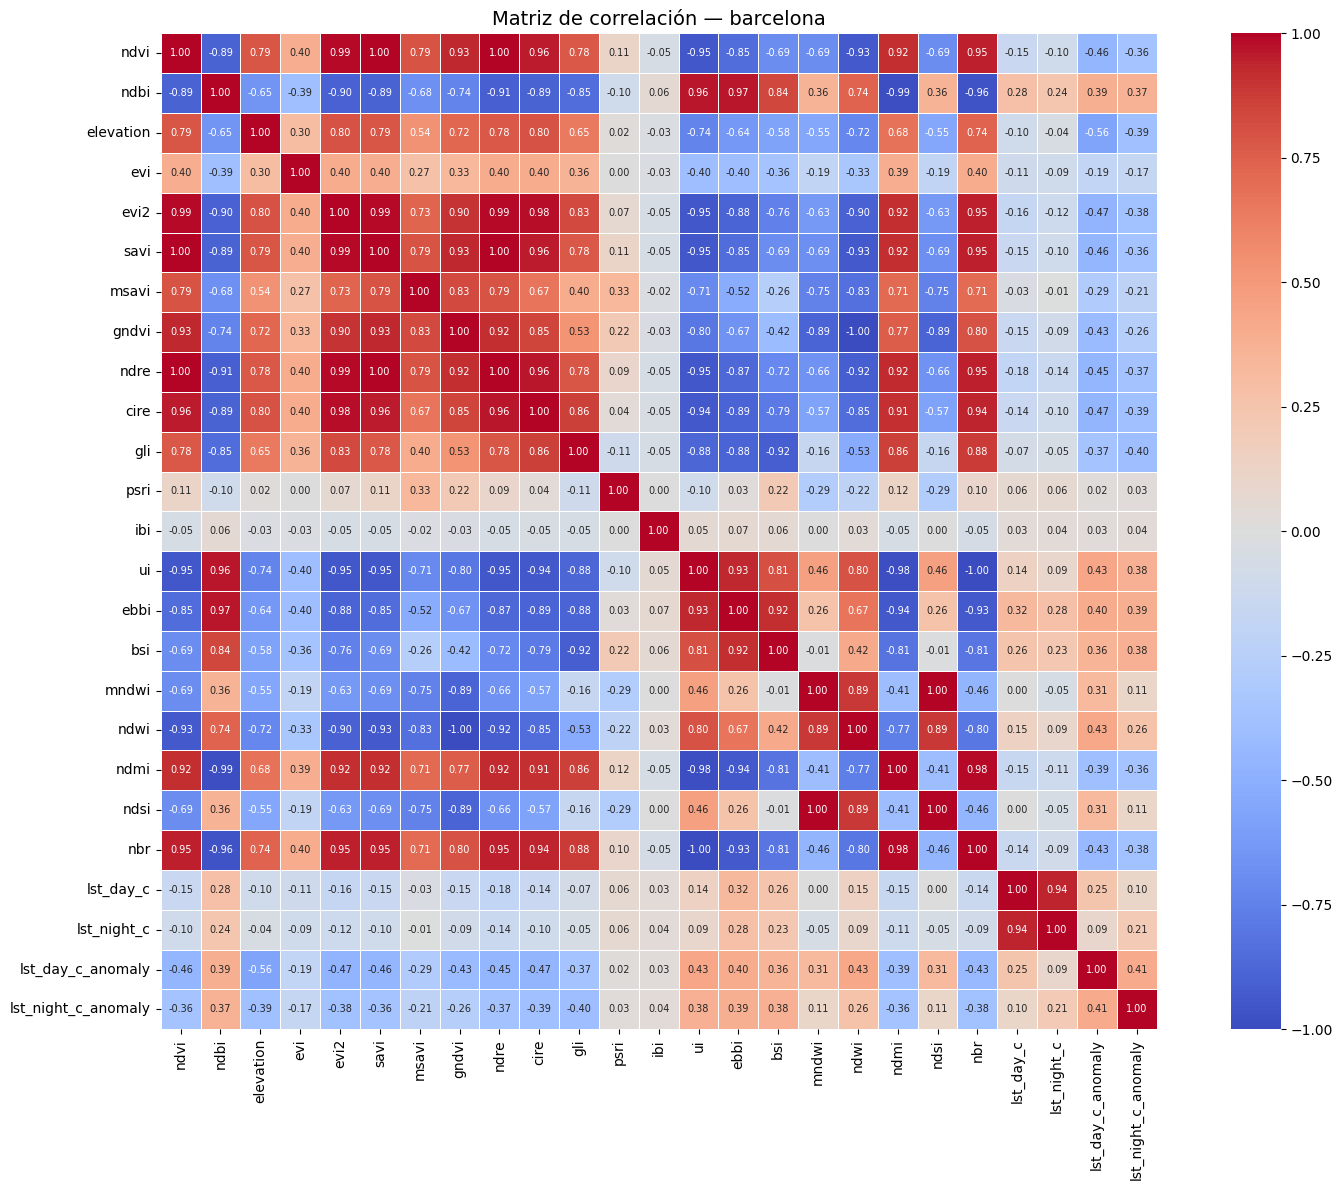

In [3]:
plt.figure(figsize=(16, 12))

cols_corr = [
    'ndvi','ndbi','elevation',
    'evi','evi2','savi','msavi','gndvi','ndre','cire','gli','psri',
    'ibi','ui','ebbi','bsi','mndwi','ndwi','ndmi','ndsi','nbr',
    'lst_day_c','lst_night_c',
    'lst_day_c_anomaly','lst_night_c_anomaly'
]

cols_corr = [c for c in cols_corr if c in dataset_final.columns]

sns.heatmap(
    dataset_final[cols_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title(f'Matriz de correlación — {CIUDAD}', fontsize=14)
plt.tight_layout()
plt.show()